# Uydu Telemetri Anomali Tespiti - Gelişmiş Modeller
Bu notebook içerisinde LightGBM, CatBoost ve Stacking Ensemble meta-modellerinin eğitimi, performans karşılaştırması ve görselleştirmeleri yapılmaktadır.

In [1]:
import os
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, f1_score, accuracy_score

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(ROOT, "data", "processed")
MODEL_DIR = os.path.join(ROOT, "models")
REPORTS_DIR = os.path.join(ROOT, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")
METRICS_DIR = os.path.join(REPORTS_DIR, "metrics")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

## 1. Veri Yükleme

In [2]:
print("Veriler yükleniyor...")
X_train = pd.read_parquet(os.path.join(DATA_DIR, "X_train.parquet"))
y_train = pd.read_parquet(os.path.join(DATA_DIR, "y_train.parquet")).values.ravel()
X_test = pd.read_parquet(os.path.join(DATA_DIR, "X_test.parquet"))
y_test = pd.read_parquet(os.path.join(DATA_DIR, "y_test.parquet")).values.ravel()

print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")

Veriler yükleniyor...


Eğitim Seti Boyutu: (2365, 19)
Test Seti Boyutu: (507, 19)


## 2. Model Tanımlamaları ve Eğitim

In [3]:
# LightGBM
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)

# CatBoost
catb = CatBoostClassifier(iterations=300, learning_rate=0.05, random_state=42, verbose=0)

# Stacking Classifier (Meta Model)
# Using strong diverse base learners
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')),
    ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
]
# Meta-learner is LogisticRegression to blend them
stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=3, n_jobs=-1)

models = {
    "LightGBM": lgbm,
    "CatBoost": catb,
    "Stacking Ensemble": stacking
}

print("Eğitim başlıyor...")
trained_models = {}
for name, model in models.items():
    print(f"{name} eğitiliyor...")
    model.fit(X_train, y_train)
    trained_models[name] = model
print("Eğitim tamamlandı!")

Eğitim başlıyor...
LightGBM eğitiliyor...


CatBoost eğitiliyor...


Stacking Ensemble eğitiliyor...


Eğitim tamamlandı!


## 3. Performans Değerlendirme ve Modellerin Kaydedilmesi


--- LightGBM ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       254
           1       0.98      0.95      0.96       253

    accuracy                           0.96       507
   macro avg       0.96      0.96      0.96       507
weighted avg       0.96      0.96      0.96       507


--- CatBoost ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       254
           1       0.98      0.95      0.96       253

    accuracy                           0.96       507
   macro avg       0.96      0.96      0.96       507
weighted avg       0.96      0.96      0.96       507




--- Stacking Ensemble ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       254
           1       0.97      0.95      0.96       253

    accuracy                           0.96       507
   macro avg       0.96      0.96      0.96       507
weighted avg       0.96      0.96      0.96       507



Tüm model dosyaları ve metrikler başarıyla kaydedildi.


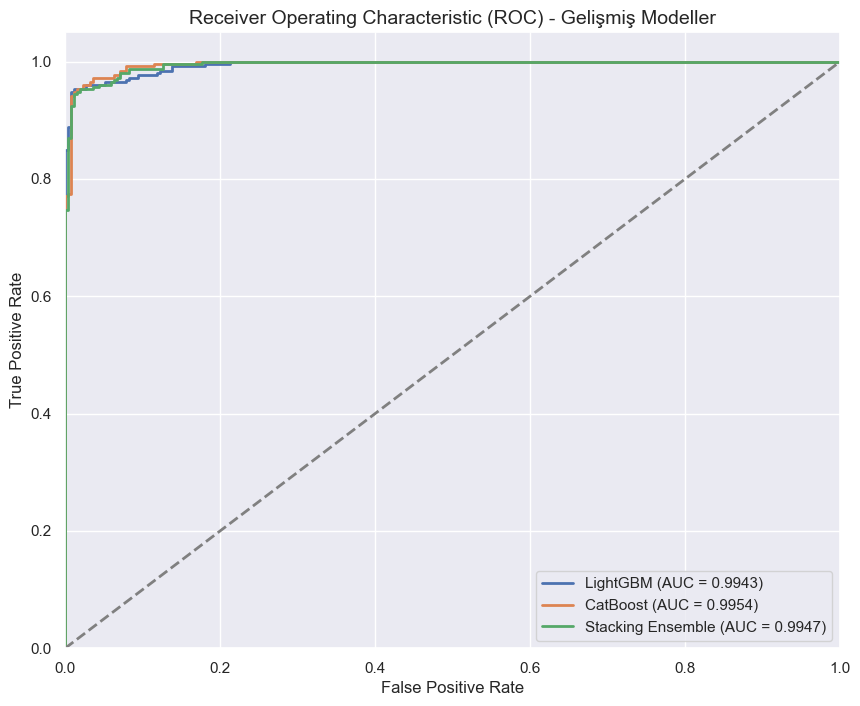

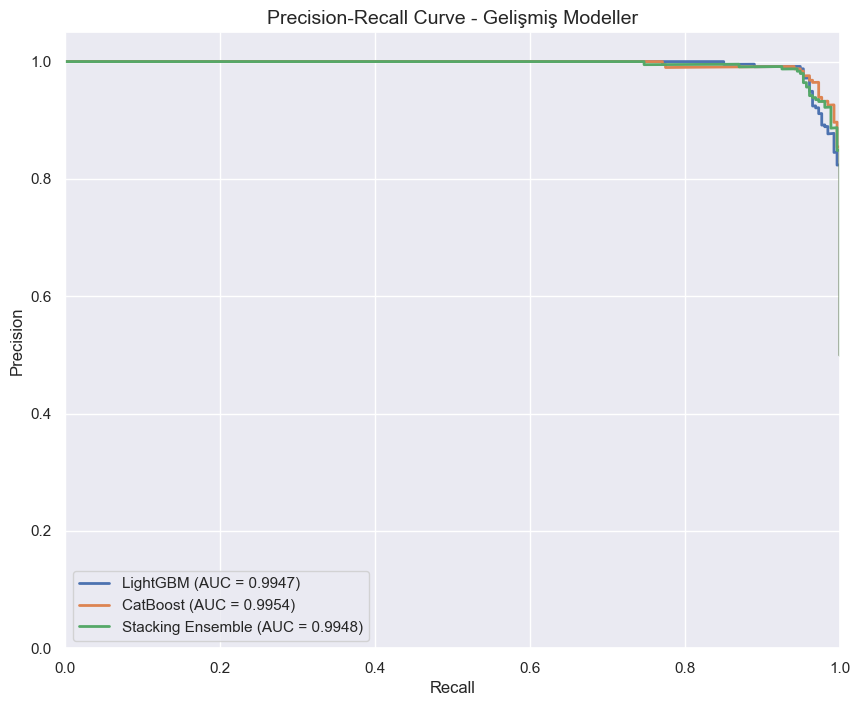

In [4]:
metrics = {}
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
fig_pr, ax_pr = plt.subplots(figsize=(10, 8))

for name, model in trained_models.items():
    # Tahminler
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrik Hesaplamaları
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    metrics[name] = {
        "Accuracy": float(acc),
        "F1 Score": float(f1),
        "ROC AUC": float(roc_auc),
        "PR AUC": float(pr_auc)
    }
    
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    
    # Eğrileri Çizdir
    ax_roc.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")
    ax_pr.plot(recall, precision, lw=2, label=f"{name} (AUC = {pr_auc:.4f})")
    
    # Modeli Kaydet
    fname = name.lower().replace(" ", "_") + "_model.joblib"
    joblib.dump(model, os.path.join(MODEL_DIR, fname))

# ROC Eğrisi Finalize Et
ax_roc.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('Receiver Operating Characteristic (ROC) - Gelişmiş Modeller', fontsize=14)
ax_roc.legend(loc="lower right")
fig_roc.savefig(os.path.join(FIGURES_DIR, "adv_roc_curves.png"), dpi=300, bbox_inches='tight')

# PR Eğrisi Finalize Et
ax_pr.set_xlim([0.0, 1.0])
ax_pr.set_ylim([0.0, 1.05])
ax_pr.set_xlabel('Recall', fontsize=12)
ax_pr.set_ylabel('Precision', fontsize=12)
ax_pr.set_title('Precision-Recall Curve - Gelişmiş Modeller', fontsize=14)
ax_pr.legend(loc="lower left")
fig_pr.savefig(os.path.join(FIGURES_DIR, "adv_pr_curves.png"), dpi=300, bbox_inches='tight')

# Metrikleri JSON'a kaydet (Arayüzde okumak için)
with open(os.path.join(METRICS_DIR, "adv_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)
    
print("Tüm model dosyaları ve metrikler başarıyla kaydedildi.")

## 4. Feature Importance Karşılaştırması

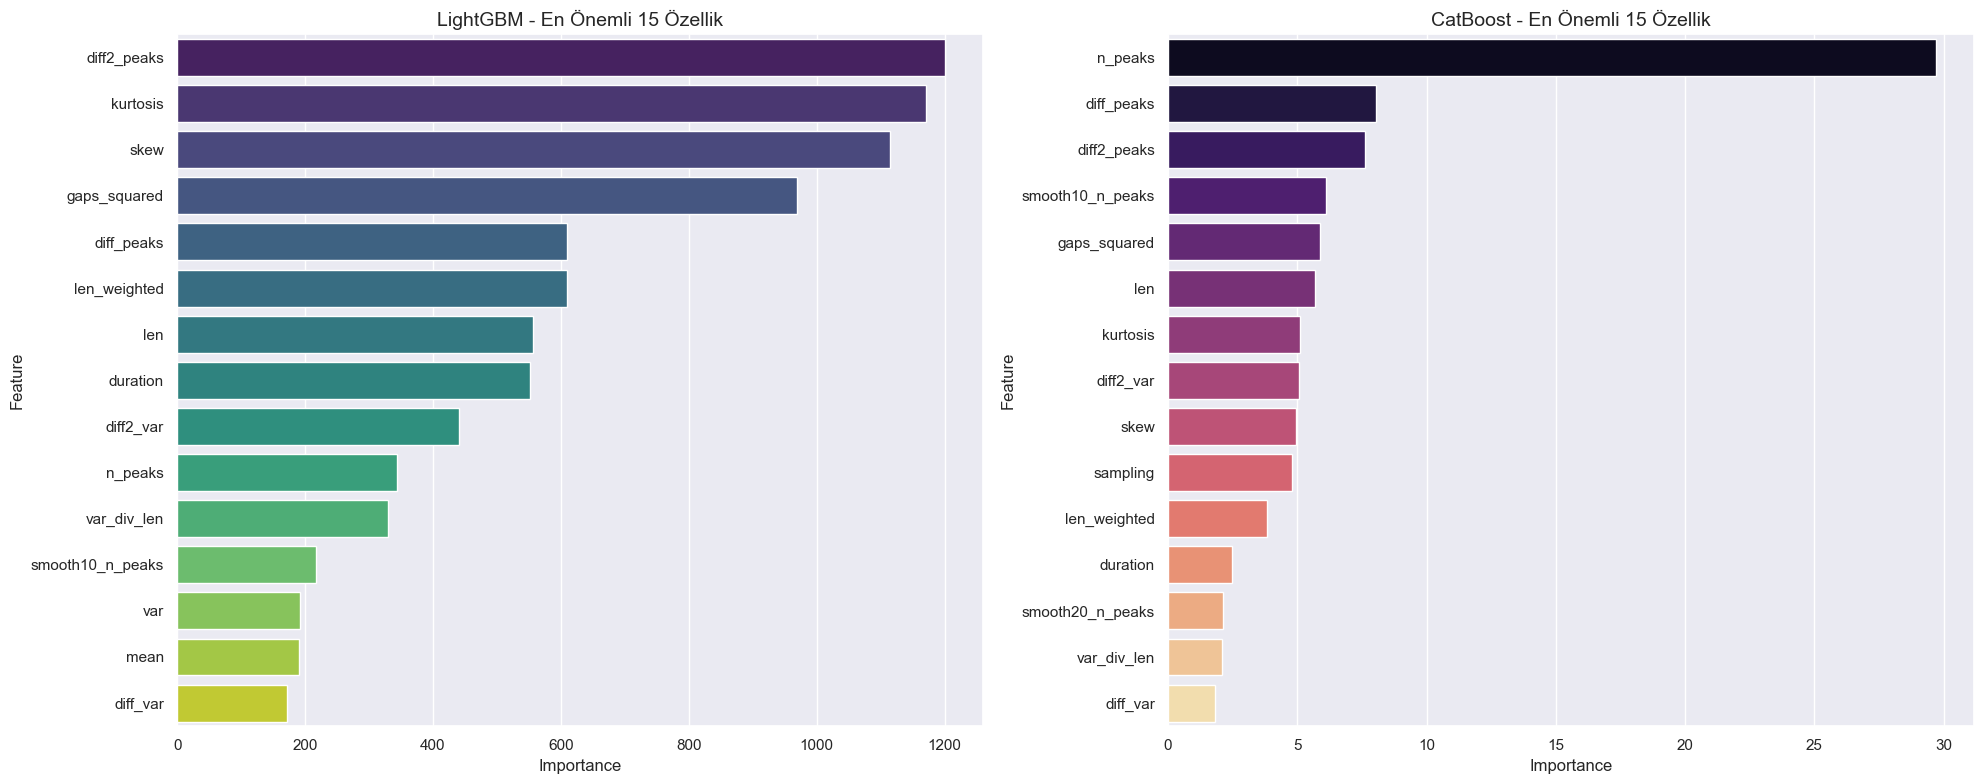

In [5]:
# LightGBM ve CatBoost Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# LGBM
lgbm_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': trained_models['LightGBM'].feature_importances_})
lgbm_imp = lgbm_imp.sort_values(by='Importance', ascending=False).head(15)
sns.barplot(x='Importance', y='Feature', data=lgbm_imp, ax=axes[0], palette='viridis')
axes[0].set_title('LightGBM - En Önemli 15 Özellik', fontsize=14)

# CatBoost
catb_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': trained_models['CatBoost'].get_feature_importance()})
catb_imp = catb_imp.sort_values(by='Importance', ascending=False).head(15)
sns.barplot(x='Importance', y='Feature', data=catb_imp, ax=axes[1], palette='magma')
axes[1].set_title('CatBoost - En Önemli 15 Özellik', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "adv_feature_importance.png"), dpi=300, bbox_inches='tight')
plt.show()